In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib import colors

In [2]:
data = pd.read_csv("T47D.csv")
#data.head()

In [3]:
#preprocess

filtered_data = data[data["phase"] != "G0"]
X = filtered_data.loc[:, 'AreaShape_Area':'Intensity_MedianIntensity_pRB']
Z = np.log(filtered_data['Metadata_well']+1).values
X = np.array(X)

5546.0
4467.0
448.0
183.0


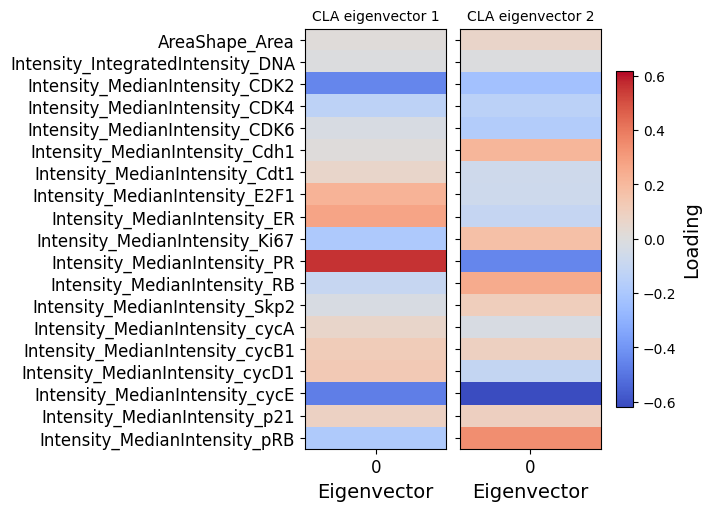

In [4]:
feature_cols = filtered_data.columns[:-3]
feature_names = feature_cols.to_numpy()
X = filtered_data.loc[:, feature_cols].to_numpy()


# ----- helpers -----
def _second_moment(X_group, center):
    n_g = X_group.shape[0]
    if n_g == 0:
        raise ValueError("Encountered an empty group.")
    if center:
        Xc = (X_group - X_group.mean(axis=0, keepdims=True))#/X_group.std(0)
        return (Xc.T @ Xc) / n_g
    else:
        return (X_group.T @ X_group) #/ n_g

def compute_CLA_matrix(X, Z, center=True, beta = 1):
    X = np.asarray(X); Z = np.asarray(Z)
    ctrl = (Z == 0)
    trt  = (Z > 0)

    Sigma0 = _second_moment(X[ctrl], center=center)
    z_treated = Z[trt]
    X_treated = X[trt]
    uniq = np.unique(z_treated)

    p = X.shape[1]
    n_plus = float(trt.sum())
    T = np.zeros((p, p), dtype=float)
    for z_val in uniq:
        idx = (z_treated == z_val)
        n_z = float(idx.sum())
        Sigma_z = _second_moment(X_treated[idx], center=center)
        print(n_z)
        T += (Sigma_z - Sigma0) / z_val*1.5
    T *= 1 / n_plus

    evals, evecs = np.linalg.eigh(T)
    order = np.argsort(evals)[::-1]
    return T, evals[order], evecs[:, order]

# --------- run CLA ----------
T, evals, evecs = compute_CLA_matrix(X, Z, center=True)

plot_second = True  

if plot_second:
    v_cla   = [evecs[:, 0], evecs[:, 1]]
    titles   = ["CLA eigenvector 1", "CLA eigenvector 2"]
    ylabels  = [True, False]   # only show feature names on the first
    ncols    = 2
else:
    v_cla   = [evecs[:, 0]]
    titles   = ["CLA eigenvector 1"]
    ylabels  = [True]
    ncols    = 1

vabs = max(np.abs(v).max() for v in v_cla)
vmin, vmax = -vabs, vabs

fig, axes = plt.subplots(1, ncols, figsize=(7, 5), constrained_layout=True)
if ncols == 1:
    axes = [axes]

for ax, vec, title, show_y in zip(axes, v_cla, titles, ylabels):
    img = ax.imshow(vec.reshape(-1, 1), aspect='auto',
                    cmap='coolwarm', vmin=vmin, vmax=vmax)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("Eigenvector", fontsize=14)
    ax.set_xticks([0]); ax.set_xticklabels(["0"], fontsize=12)

    ax.set_yticks(np.arange(len(feature_names)))
    if show_y:
        ax.set_yticklabels(feature_names, fontsize=12)
    else:
        ax.set_yticklabels([])

cbar = fig.colorbar(img, ax=axes, shrink=0.8)
cbar.set_label("Loading", fontsize=14)

plt.show()


In [5]:
def cov_mle(A):
    A = np.asarray(A)
    A_c = A - A.mean(axis=0, keepdims=True)
    n = A.shape[0]
    return (A_c.T @ A_c) / n

def first_cpca_vector(X_fg, X_bg):
    Sigma_fg = cov_mle(X_fg)
    Sigma_bg = cov_mle(X_bg)
    alpha = 1
    T = Sigma_fg - alpha * Sigma_bg
    evals, evecs = np.linalg.eigh(T)            
    order = np.argsort(evals)[::-1]             
    return evecs[:, order][:, 0]                

cols = []
labels = []

# CLA
v_cla_vec = np.asarray(v_cla[0]).reshape(-1)
cols.append(v_cla_vec)
labels.append("CLA")

# CPCA
X_fg_all = X[Z > 0]
X_bg_all = X[Z == 0]
v_cpca_all = first_cpca_vector(X_fg_all, X_bg_all)
cols.append(v_cpca_all)
labels.append("CPCA (Pooled)")

Y = X[Z!=0]

# 3) CPCA for each Z
unique_nonzero_z = np.sort(np.unique(Z[Z != 0]))

skipped = 0
for z in unique_nonzero_z:
    X_fg_z = X[Z == z]
    v_cpca_z = first_cpca_vector(X_fg_z, Y)
    cols.append(v_cpca_z)
    labels.append(f"{int(np.round(np.exp(float(z)) - 1, 1))}")

eigmat = np.stack(cols, axis=1)   



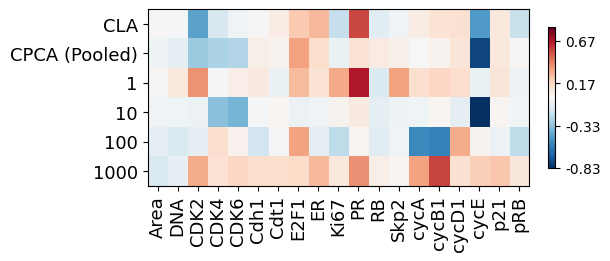

In [7]:
#plot

ref = eigmat[:, 0]
ref = ref / (np.linalg.norm(ref) + 1e-12)
for j in range(eigmat.shape[1]):
    col = eigmat[:, j]
    if np.dot(col, ref) < 0:
        eigmat[:, j] = -col


vabs = eigmat.max()
vmin = eigmat.min()
vmin, vmax = vmin, vabs  

fig_height = max(2.5, len(labels) * 0.25)
fig_width  = max(6, 0.3 * len(feature_names))
fig, ax = plt.subplots(figsize=(fig_width, fig_height), constrained_layout=True)

eigmat_plot = eigmat.T

norm = colors.TwoSlopeNorm(
    vmin=-np.max(np.abs(eigmat_plot)),
    vcenter=0.0,
    vmax= np.max(np.abs(eigmat_plot))
)

img = ax.imshow(
    eigmat_plot,
    aspect='auto',
    cmap='RdBu_r',
    norm=norm
)


simplified_features = np.array([
    name.split('_')[-1] for name in feature_names
])

ax.set_xticks(np.arange(len(simplified_features)))
ax.set_xticklabels(simplified_features, fontsize=13, rotation=90)

ax.set_yticks(np.arange(len(labels)))
ax.set_yticklabels(labels, fontsize=13)


cbar = fig.colorbar(img, ax=ax, shrink=0.8)
cbar.set_ticks(np.linspace(vmin, vmax, 4))  
cbar.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
#fig.savefig("/Users/ericzhang/Library/CloudStorage/OneDrive-UniversityofNorthCarolinaatChapelHill/dissertation work/project 3 - contrastive la/t47d_eig1_T.png", dpi=300, bbox_inches="tight")
plt.show()



array([ 0.01150034, -0.00734816, -0.4485823 , -0.13275343, -0.02755623,
        0.0073683 ,  0.0622564 ,  0.21915768,  0.27120255, -0.19138823,
        0.55826224, -0.09674471, -0.02725329,  0.05866   ,  0.11367848,
        0.12861354, -0.47012601,  0.08573923, -0.18716411])

In [9]:
abs1 = abs(v_cla_vec)

mask = abs1 > abs2

# -------------------------------------------------
# 2. Apply mask
# -------------------------------------------------
df_filtered = pd.DataFrame({
    "feature": simplified_features[mask],
    "eig1_abs": abs1[mask],
    "eig2_abs": abs2[mask],
    "diff": diff[mask]
})

# -------------------------------------------------
# 3. Sort by difference
# -------------------------------------------------
df_filtered_sorted = df_filtered.sort_values(by="diff", ascending=False)

# -------------------------------------------------
# 4. Top features
# -------------------------------------------------
top_k = 20
top_features = df_filtered_sorted.head(top_k)

print(top_features)

NameError: name 'abs1' is not defined